# <center>Skin Cancer MNIST: HAM10000 — Improved</center>

**Course:** COSE474 — Deep Learning  
**Team:** Sanghyeok Jeong · Fok Ching Yin · Nur Izazi

### Improvements over baseline
| # | Problem in Baseline | Our Fix |
|---|---|---|
| 1 | Training from scratch on ~7k images → underfitting | Transfer Learning with **ResNet18** (ImageNet pretrained) |
| 2 | Standard cross-entropy ignores class imbalance | **Focal Loss** (γ=2) automatically down-weights easy majority samples |
| 3 | Only overall accuracy reported; black-box model | **Grad-CAM** heatmaps + per-class Recall + AUC |
| 4 | Minimal augmentation → overfitting | Domain-safe augmentation: flips + rotation + colour jitter |

### 1. Importing Essential Libraries

In [85]:
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import seaborn as sns
import os
import itertools
import time
from glob import glob
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, recall_score)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


### 2. Helper Functions

##### Function to plot model accuracy and loss over epochs

In [86]:
def plot_model_history(train_losses, val_losses, train_accs, val_accs, name='Model'):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(train_accs, label='Train Accuracy')
    axs[0].plot(val_accs,   label='Val Accuracy')
    axs[0].set_title(f'{name} — Accuracy')
    axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('Accuracy')
    axs[0].legend()

    axs[1].plot(train_losses, label='Train Loss')
    axs[1].plot(val_losses,   label='Val Loss')
    axs[1].set_title(f'{name} — Focal Loss')
    axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Loss')
    axs[1].legend()

    plt.tight_layout()
    plt.savefig(f'Photos/{name}_history.png', dpi=150)
    plt.show()

##### Function to plot confusion matrix

In [87]:
def plot_confusion_matrix(cm, classes, name, normalize=False,
                          title='Confusion Matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(f'Photos/{name}_confusion_matrix.png', dpi=150)
    plt.show()

##### Function to generate classification report with per-class metrics
> **Improvement 3** — baseline only reported overall accuracy; this exposes per-class Precision, Recall, and F1.

In [88]:
def gen_classification_report(y_true, y_pred, class_names):
    print(classification_report(y_true, y_pred, target_names=class_names))

##### Function to plot per-class recall bar chart
> **Improvement 3** — visualises which minority classes (e.g. melanoma) the model fails on.

In [89]:
def plot_per_class_recall(y_true, y_pred, class_names, name):
    recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
    colors = ['#d62728' if r < 0.5 else '#2ca02c' for r in recalls]
    plt.figure(figsize=(9, 5))
    bars = plt.bar(class_names, recalls, color=colors, edgecolor='black')
    plt.axhline(0.5, color='grey', linestyle='--', alpha=0.7, label='50% threshold')
    plt.ylim(0, 1.1)
    plt.ylabel('Recall')
    plt.title(f'{name} — Per-Class Recall (red = below 50%)')
    plt.legend()
    for bar, v in zip(bars, recalls):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{v:.2f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'Photos/{name}_per_class_recall.png', dpi=150)
    plt.show()

### 3. Creating a Dictionary of Images and their Labels

##### Download dataset via KaggleHub — `path` is the local dataset root

In [90]:
BASE_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", BASE_DIR)

Dataset path: /Users/alice/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


##### Retrieving image names from all sub-folders and placing them in a dictionary

In [91]:
imageid_path_dict = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(BASE_DIR, '**', '*.jpg'), recursive=True)
}
print(f"Total images found: {len(imageid_path_dict)}")

Total images found: 10015


##### Diagnostic skin lesion categories dictionary

In [92]:
lesion_type_dict = {
    'nv':    'Melanocytic nevi',
    'mel':   'Melanoma',
    'bkl':   'Benign keratosis-like lesions',
    'bcc':   'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc':  'Vascular lesions',
    'df':    'Dermatofibroma'
}
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']  # alphabetical by dx code

### 4. Importing Dataset

##### Reading dataset CSV from the kagglehub-provided path

In [93]:
skin_df = pd.read_csv(os.path.join(BASE_DIR, 'HAM10000_metadata.csv'))
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### 5. Reading & Processing Dataset

##### Adding new columns for path, full class name, and integer label index

In [94]:
skin_df['path']          = skin_df['image_id'].map(imageid_path_dict.get)
skin_df['cell_type']     = skin_df['dx'].map(lesion_type_dict.get)
skin_df['cell_type_idx'] = pd.Categorical(skin_df['cell_type']).codes
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/Users/alice/.cache/kagglehub/datasets/kmader/...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/Users/alice/.cache/kagglehub/datasets/kmader/...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/Users/alice/.cache/kagglehub/datasets/kmader/...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/Users/alice/.cache/kagglehub/datasets/kmader/...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/Users/alice/.cache/kagglehub/datasets/kmader/...,Benign keratosis-like lesions,2


##### View dataset statistics

In [95]:
skin_df.describe(exclude=[np.number])

,lesion_id,image_id,dx,dx_type,sex,localization,path,cell_type
count,10015,10015,10015,10015,10015,10015,10015,10015
unique,7470,10015,7,4,3,15,10015,7
top,HAM_0003789,ISIC_0027419,nv,histo,male,back,/Users/alice/.cache/kagglehub/datasets/kmader/...,Melanocytic nevi
freq,6,1,6705,5340,5406,2192,1,6705


In [96]:
skin_df.describe()

,age,cell_type_idx
count,9958.000000,10015.000000
mean,51.863828,3.623964
std,16.968614,1.208859
min,0.000000,0.000000
25%,40.000000,4.000000
50%,50.000000,4.000000
75%,65.000000,4.000000
max,85.000000,6.000000


In [97]:
print(skin_df.dtypes)

lesion_id         object
image_id          object
dx                object
dx_type           object
age              float64
sex               object
localization      object
path              object
cell_type         object
cell_type_idx       int8
dtype: object


### 6. Cleaning Dataset

##### Drop duplicate lesion_ids — keep one image per unique lesion

In [98]:
skin_df = skin_df.drop_duplicates(subset='lesion_id')
print(f"Dataset size after dedup: {len(skin_df)}")

Dataset size after dedup: 7470


##### Check for and fill missing age values

In [99]:
print("Missing values before fill:")
print(skin_df.isnull().sum())
skin_df['age'].fillna(skin_df['age'].mean(), inplace=True)
print("\nMissing values after fill:")
print(skin_df.isnull().sum())

Missing values before fill:
lesion_id         0
image_id          0
dx                0
dx_type           0
age              52
sex               0
localization      0
path              0
cell_type         0
cell_type_idx     0
dtype: int64

Missing values after fill:
lesion_id        0
image_id         0
dx               0
dx_type          0
age              0
sex              0
localization     0
path             0
cell_type        0
cell_type_idx    0
dtype: int64


### 7. Exploratory Data Analysis (EDA)

##### Visualise the 7 skin lesion category distributions

> Note the severe class imbalance — ~67% of images are Melanocytic nevi (`nv`). This is the root cause of Problems 2 and 4.

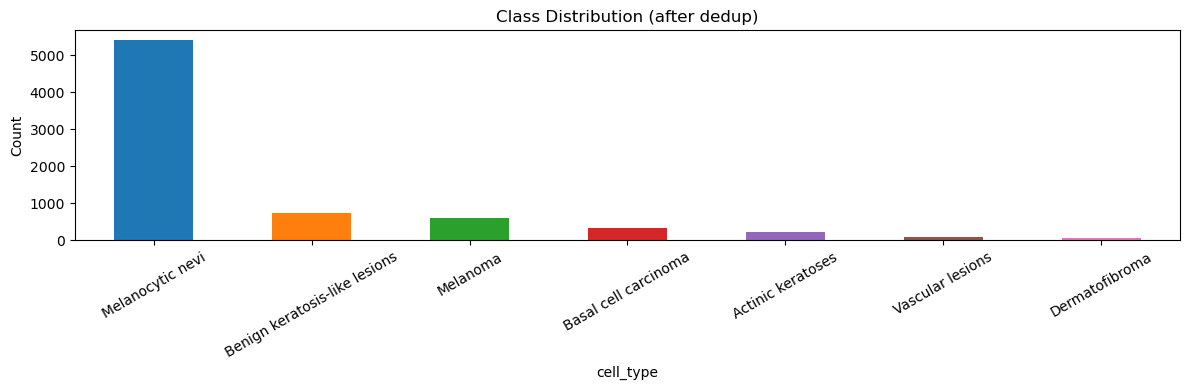

dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: count, dtype: int64


In [100]:
plt.figure(figsize=(12, 4))
skin_df['cell_type'].value_counts().plot(kind='bar',
    color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2'])
plt.title('Class Distribution (after dedup)')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('Photos/class_distribution.png', dpi=150)
plt.show()
print(skin_df['dx'].value_counts())

##### Visualise age distribution

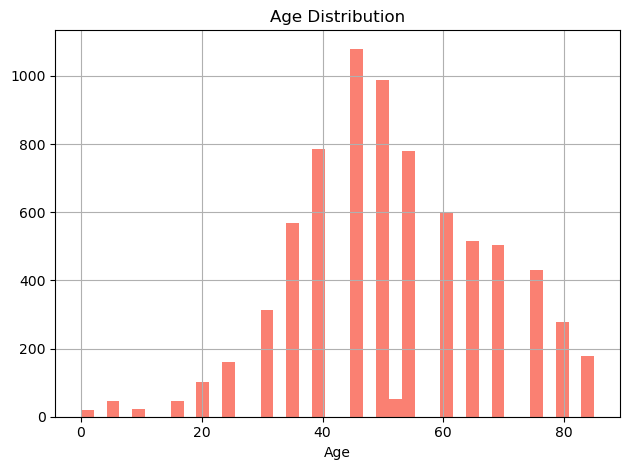

In [101]:
skin_df['age'].hist(bins=40, color='salmon')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.tight_layout()
plt.savefig('Photos/age_distribution.png', dpi=150)
plt.show()

##### Show sample images from each of the 7 categories

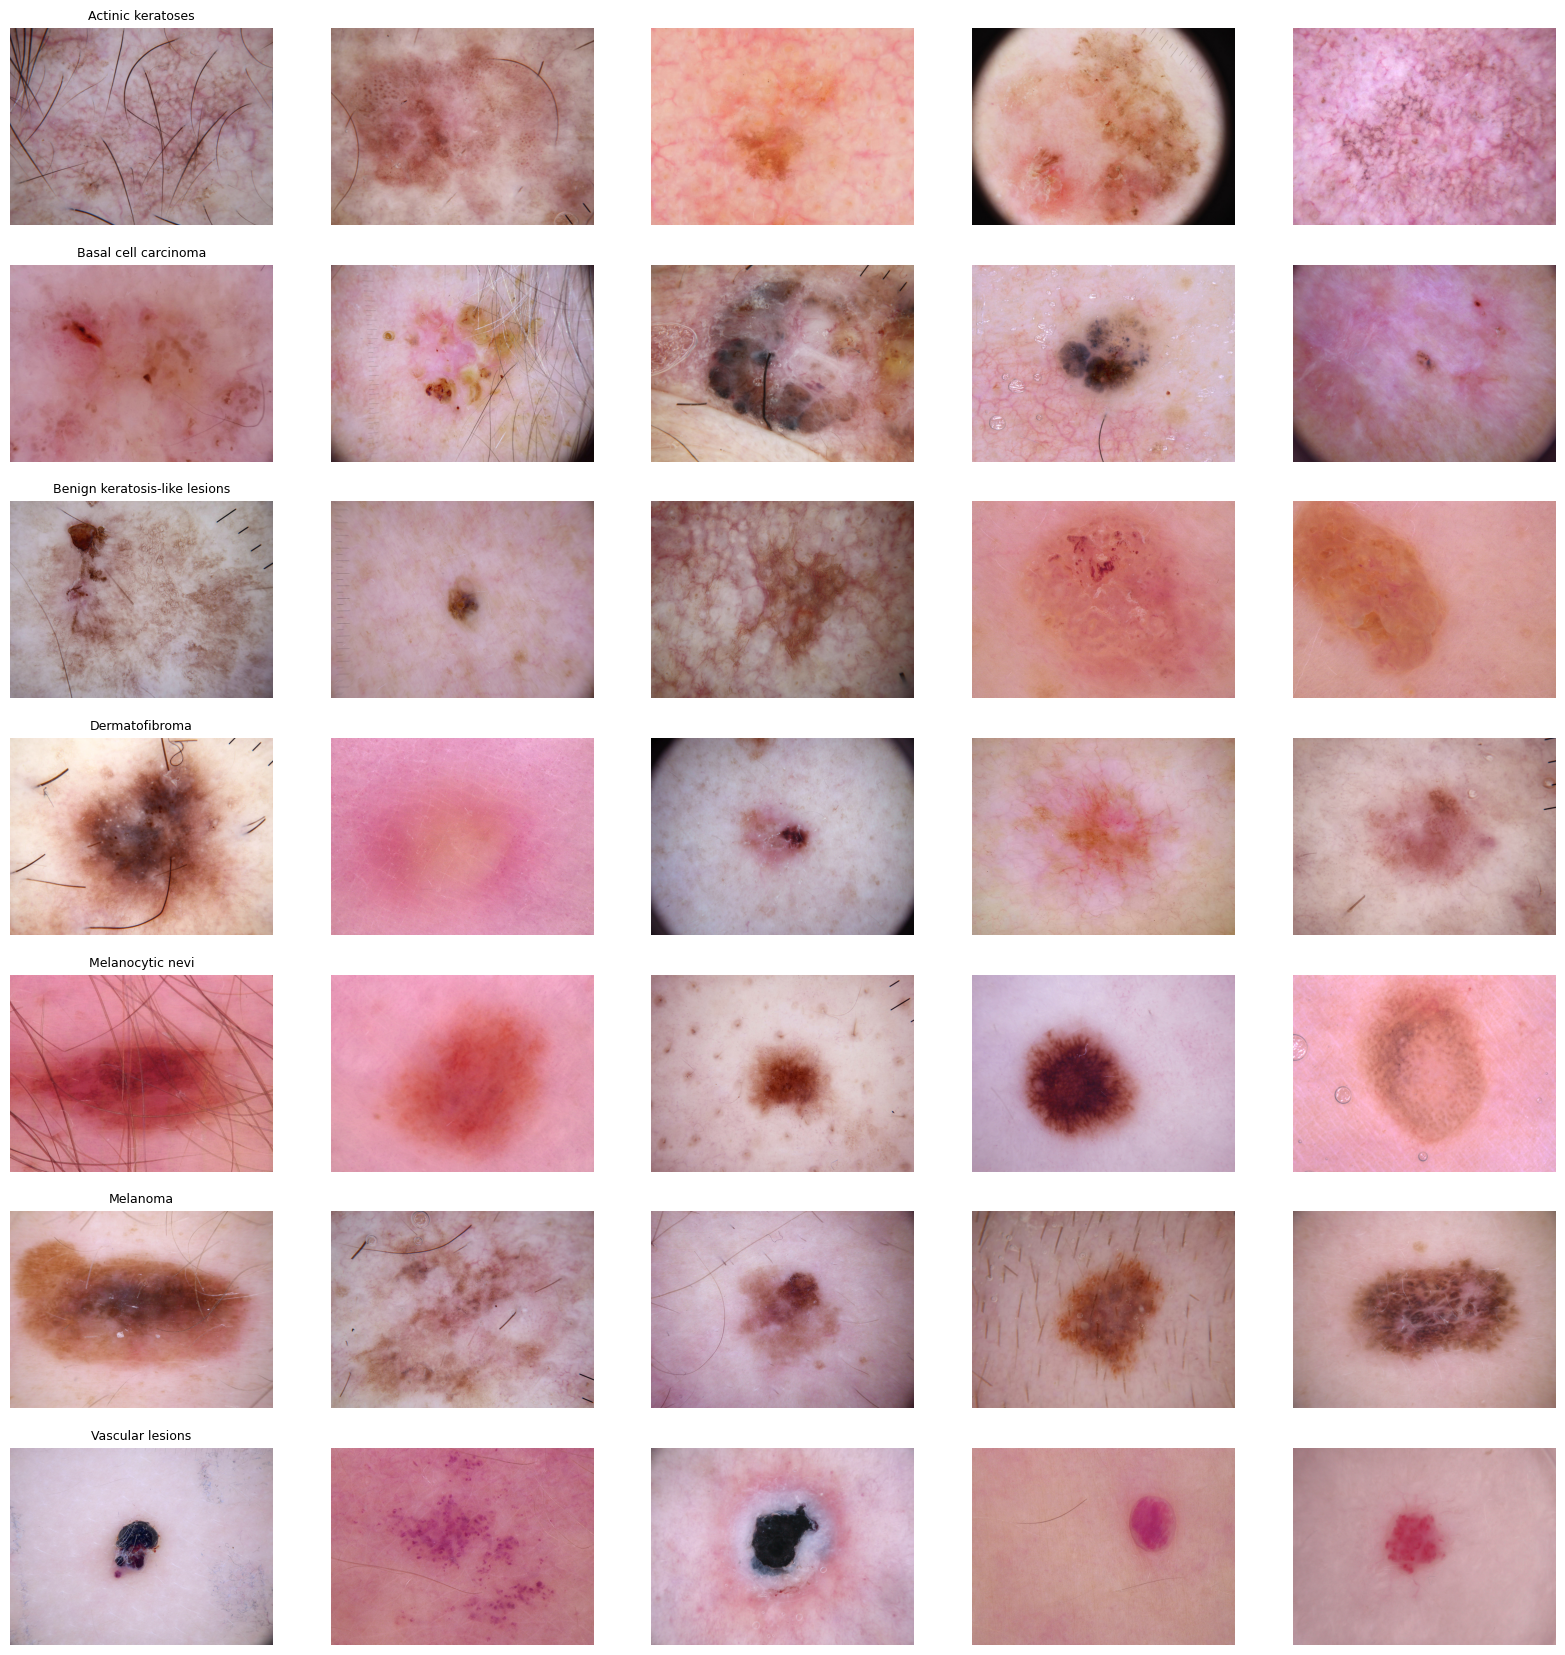

In [102]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize=(4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs,
                                          skin_df.sort_values('cell_type').groupby('cell_type')):
    n_axs[0].set_title(type_name, fontsize=9)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(min(n_samples, len(type_rows)), random_state=42).iterrows()):
        c_ax.imshow(Image.open(c_row['path']))
        c_ax.axis('off')
fig.savefig('Photos/category_samples.png', dpi=150)
plt.show()

### 8. Processing & Resizing Images

> **Improvement 1** — Baseline resized to 75×100 (÷4). ResNet18 requires **224×224**, which also preserves more detail for fine-tuning.

##### Set image size to 224×224 as required by ResNet18

In [103]:
IMG_SIZE = 224
print(f"Target image size: {IMG_SIZE}×{IMG_SIZE}")

Target image size: 224×224


### 9. Features and Target Split

In [104]:
features = skin_df.drop(columns=['cell_type_idx'], axis=1)
target   = skin_df['cell_type_idx']
print(f"Features shape: {features.shape} | Target shape: {target.shape}")

Features shape: (7470, 9) | Target shape: (7470,)


### 10. Training, Validation, and Test Split

Stratified split preserving class proportions: **70% Train · 10% Val · 20% Test**

In [105]:
# 80:20 stratified train-test split
X_train_df, X_test_df, y_train, y_test = train_test_split(
    features, target, test_size=0.20, stratify=target, random_state=SEED)

# 87.5:12.5 train-val split (giving 70:10 overall)
X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_train_df, y_train, test_size=0.125, stratify=y_train, random_state=SEED)

X_train_paths = X_train_df['path'].values
X_val_paths   = X_val_df['path'].values
X_test_paths  = X_test_df['path'].values
y_train = y_train.values
y_val   = y_val.values
y_test  = y_test.values

print(f"Train: {len(X_train_paths)} | Val: {len(X_val_paths)} | Test: {len(X_test_paths)}")

Train: 5229 | Val: 747 | Test: 1494


### 11. Class Weights

> Retained from baseline for reference. In our improved model, **Focal Loss handles imbalance automatically**, so class weights are not passed to the training loop. They are still computed here for analysis.

In [106]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Computed class weights:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i} ({name:8s}): {class_weights[i]:.3f}")

Computed class weights:
  0 (akiec   ): 4.698
  1 (bcc     ): 3.262
  2 (bkl     ): 1.468
  3 (df      ): 14.647
  4 (mel     ): 0.197
  5 (nv      ): 1.737
  6 (vasc    ): 10.985


### 12. Data Augmentation

> **Improvement 4 — Domain-Safe Augmentation**  
> The baseline applied only rotation, zoom, and shifts via Keras `ImageDataGenerator`. We add clinically validated transforms:
> - `RandomHorizontalFlip` / `RandomVerticalFlip` — lesions have no canonical orientation  
> - `RandomRotation(30°)` — rotated lesion is medically identical  
> - `ColorJitter` — simulates variation in imaging hardware across hospitals  
> - ImageNet normalisation is required because ResNet18 weights were trained on ImageNet stats

##### Define and initialise augmented data transforms (training set only)

In [107]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),                       # clinically valid
    transforms.RandomVerticalFlip(),                         # clinically valid
    transforms.RandomRotation(degrees=30),                   # no canonical orientation
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),         # hardware variation
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation and test sets: only resize + normalise — NO augmentation
# (prevents data leakage and ensures fair evaluation)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("Transforms defined.")

Transforms defined.


##### PyTorch Dataset class — loads images on-the-fly from disk paths

In [108]:
class SkinLesionDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img   = Image.open(self.image_paths[idx]).convert('RGB')
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label

os.makedirs('Models', exist_ok=True)
os.makedirs('Photos', exist_ok=True)

BATCH_SIZE = 32

train_dataset = SkinLesionDataset(X_train_paths, y_train, transform=train_transform)
val_dataset   = SkinLesionDataset(X_val_paths,   y_val,   transform=val_test_transform)
test_dataset  = SkinLesionDataset(X_test_paths,  y_test,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches — Train: 164 | Val: 24 | Test: 47


### 13. Improved CNN — ResNet18 with Transfer Learning

> **Improvement 1 — Transfer Learning with ResNet18**  
> **Fixes:** Problem 1 — Training from Scratch on Insufficient Data  
> **Course:** Week 7 (Training Neural Networks), Week 8 (CNN Architecture)
>
> The baseline's custom CNN is trained entirely from zero on ~5,800 training images across 7 classes — far too few for a deep network to learn meaningful features, leading to ~77% accuracy.
>
> We replace it with a **pretrained ResNet18** (ImageNet, 1.2M images):
> - Freeze the convolutional backbone — reuse rich pretrained features
> - Replace only the final FC layer with a new 7-class head
> - ResNet18's **skip (residual) connections** prevent vanishing gradient (Week 8)
> - Fine-tune via **progressive unfreezing**: train head only for 5 epochs, then unfreeze the full network at a lower LR to avoid catastrophic forgetting

##### Build the ResNet18 model with frozen backbone

In [109]:
NUM_CLASSES = 7
LR          = 1e-4
EPOCHS      = 30
UNFREEZE_EPOCH = 5  # warm-up head for 5 epochs before unfreezing backbone

def build_resnet18(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC — always trainable
    in_features = model.fc.in_features   # 512 for ResNet18
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model


model = build_resnet18(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Trainable params: 133,127 / 11,309,639 (1.2%)


### 14. Focal Loss

> **Improvement 2 — Focal Loss**  
> **Fixes:** Problem 2 — Standard Cross-Entropy Ignores Class Imbalance  
> **Course:** Week 4 (Loss Functions and Optimization)
>
> The baseline uses `categorical_crossentropy`, which assigns equal weight to every sample regardless of class. With ~67% benign `nv` samples, the model is rewarded for always predicting the majority class.
>
> **Focal Loss** (Lin et al., ICCV 2017): `FL(p_t) = −α(1−p_t)^γ log(p_t)`
> - The modulating factor `(1−p_t)^γ` **down-weights easy, well-classified samples** automatically
> - Forces gradient updates to focus on **hard, misclassified minority cases** like melanoma
> - γ=2 is the recommended default from the original RetinaNet paper
> - No manual dataset resampling needed

##### Define Focal Loss

In [110]:
class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        gamma: focusing parameter. gamma=0 reduces to standard cross-entropy.
        alpha: per-class weight tensor of shape (num_classes,), or None.
        reduction: 'mean' or 'sum'.
    """
    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_probs = F.log_softmax(logits, dim=1)         # (N, C)
        probs     = torch.exp(log_probs)                 # (N, C)

        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # (N,)
        pt     = probs.gather(1,     targets.unsqueeze(1)).squeeze(1)  # (N,)

        focal_weight = (1 - pt) ** self.gamma
        loss = -focal_weight * log_pt

        if self.alpha is not None:
            loss = self.alpha[targets] * loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()


criterion = FocalLoss(gamma=2.0)
print("Loss: FocalLoss(gamma=2.0)")

Loss: FocalLoss(gamma=2.0)


### 15. Setting the Optimizer and Scheduler

##### Phase 1: train only the new classification head (backbone frozen)

In [111]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

# Reduce LR when val accuracy plateaus — mirrors baseline's ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, min_lr=1e-6
)

print('Optimizer: Adam | Scheduler: ReduceLROnPlateau')

Optimizer: Adam | Scheduler: ReduceLROnPlateau


### 16. Training the Model

**Progressive unfreezing strategy:**
- Epochs 1–5: Train only the new FC head (backbone frozen) — avoids corrupting pretrained features
- Epoch 6 onwards: Unfreeze all layers, fine-tune with backbone LR = LR×0.1 to prevent catastrophic forgetting

##### Single epoch training/validation function

In [112]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total

##### Fit the model with real-time data augmentation and early stopping

In [113]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc  = 0.0
MODEL_SAVE    = 'Models/resnet18_improved.pth'
start_time    = time.time()

print(f'Training for {EPOCHS} epochs on {DEVICE}\n')

for epoch in range(1, EPOCHS + 1):

    # ── Progressive unfreezing at epoch UNFREEZE_EPOCH+1 ──────────────────
    if epoch == UNFREEZE_EPOCH + 1:
        print(f'\n[Epoch {epoch}] Unfreezing backbone — fine-tuning entire network at lower LR.')
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam([
            {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': LR * 0.1},
            {'params': model.fc.parameters(),                                      'lr': LR}
        ])
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', patience=3, factor=0.5, min_lr=1e-7
        )

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)
    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    tag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE)
        tag = '  ← best'

    print(f'Epoch {epoch:2d}/{EPOCHS}  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%{tag}')

elapsed = time.time() - start_time
print(f'\nTraining complete in {elapsed/60:.1f} min. Best val acc: {best_val_acc*100:.2f}%')

Training for 30 epochs on cpu

Epoch  1/30  Train Loss: 0.6370  Train Acc: 70.55%  Val Loss: 0.5074  Val Acc: 75.10%  ← best
Epoch  2/30  Train Loss: 0.5111  Train Acc: 73.25%  Val Loss: 0.4601  Val Acc: 75.77%  ← best
Epoch  3/30  Train Loss: 0.4765  Train Acc: 74.03%  Val Loss: 0.4333  Val Acc: 76.84%  ← best
Epoch  4/30  Train Loss: 0.4492  Train Acc: 75.12%  Val Loss: 0.4138  Val Acc: 76.57%
Epoch  5/30  Train Loss: 0.4390  Train Acc: 74.85%  Val Loss: 0.4070  Val Acc: 75.64%

[Epoch 6] Unfreezing backbone — fine-tuning entire network at lower LR.
Epoch  6/30  Train Loss: 0.3956  Train Acc: 76.34%  Val Loss: 0.3428  Val Acc: 79.65%  ← best
Epoch  7/30  Train Loss: 0.3395  Train Acc: 78.71%  Val Loss: 0.3174  Val Acc: 80.46%  ← best
Epoch  8/30  Train Loss: 0.3129  Train Acc: 80.07%  Val Loss: 0.2975  Val Acc: 81.26%  ← best
Epoch  9/30  Train Loss: 0.2858  Train Acc: 81.05%  Val Loss: 0.2896  Val Acc: 79.79%
Epoch 10/30  Train Loss: 0.2681  Train Acc: 81.68%  Val Loss: 0.2742  Val 

##### Total time taken to train the model

In [114]:
print(f'Total training time: {elapsed/60:.1f} min')

Total training time: 144.9 min


##### Saving the model

In [115]:
# Model checkpoint already saved during training to MODEL_SAVE
print(f'Best model saved to: {MODEL_SAVE}')

Best model saved to: Models/resnet18_improved.pth


### 17. Training History

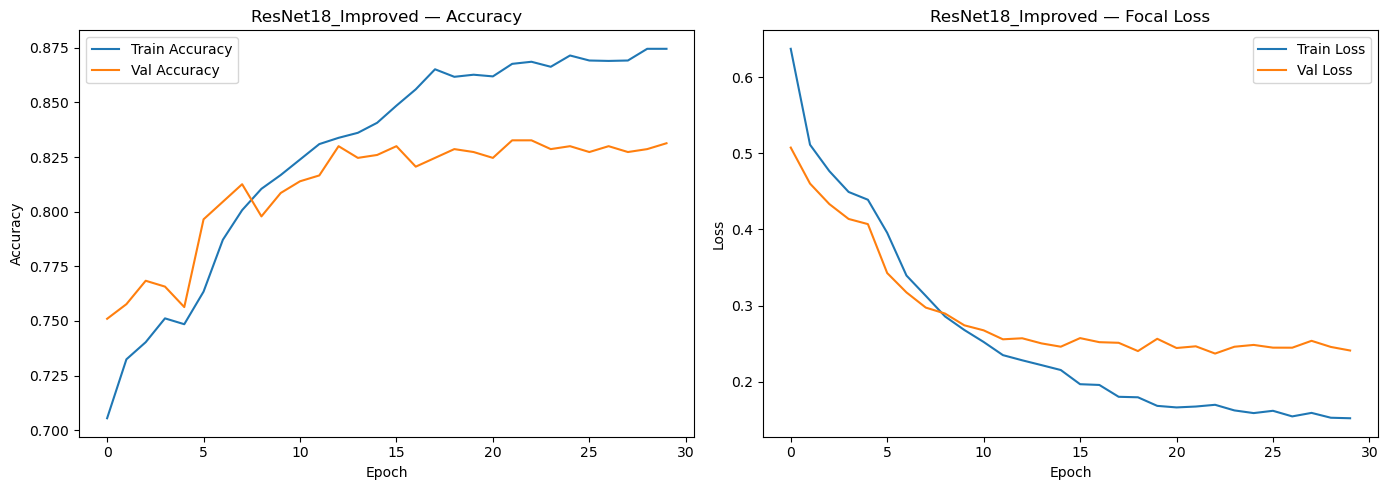

In [116]:
plot_model_history(
    history['train_loss'], history['val_loss'],
    history['train_acc'],  history['val_acc'],
    name='ResNet18_Improved'
)

### 18. Loading the Saved Model

In [117]:
model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model.eval()
print(f'Best model loaded from: {MODEL_SAVE}')

Best model loaded from: Models/resnet18_improved.pth


### 19. Model Evaluation on Test Set

##### Collect all predictions, true labels, and probability scores

In [118]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(DEVICE))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

overall_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {overall_acc*100:.2f}%')

Test Accuracy: 83.20%


##### Training + Validation set accuracy (mirrors baseline reporting)

In [119]:
train_loss_f, train_acc_f = run_epoch(model, train_loader, criterion)
val_loss_f,   val_acc_f   = run_epoch(model, val_loader,   criterion)

print(f"Training Accuracy: {train_acc_f*100:.2f}%")
print(f"Validation Accuracy: {val_acc_f*100:.2f}%")
print(f"\nTraining Loss: {train_loss_f:.4f}")
print(f"Validation Loss: {val_loss_f:.4f}")

Training Accuracy: 88.77%
Validation Accuracy: 83.27%

Training Loss: 0.1308
Validation Loss: 0.2467


### 20. Testing Set Confusion Matrix for True vs Predicted Labels

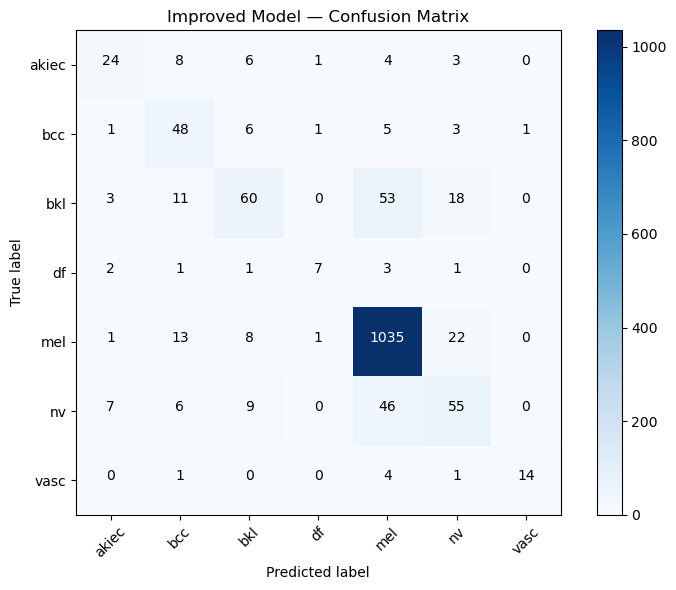

In [120]:
cm = confusion_matrix(all_labels, all_preds)
plot_confusion_matrix(cm, CLASS_NAMES, name='ResNet18_Improved',
                      title='Improved Model — Confusion Matrix')

##### Normalised confusion matrix

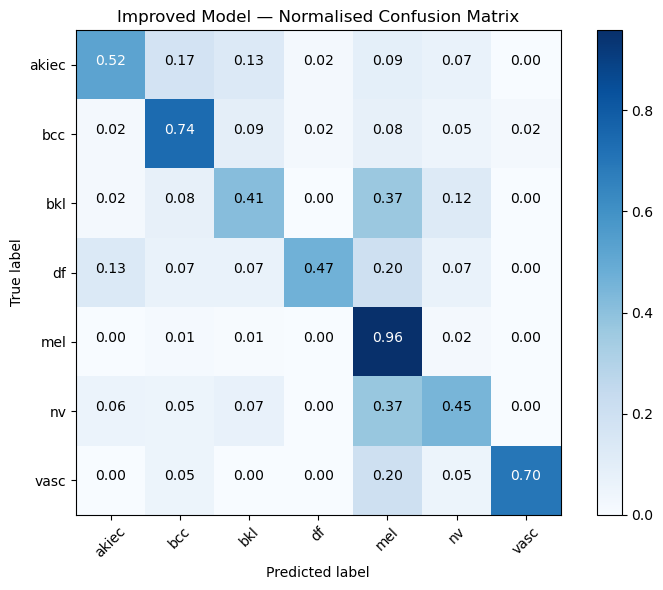

In [121]:
plot_confusion_matrix(cm, CLASS_NAMES, name='ResNet18_Improved_Norm',
                      normalize=True, title='Improved Model — Normalised Confusion Matrix')

### 21. Classification Report + Per-Class Metrics

> **Improvement 3 — Per-Class Metrics**  
> **Fixes:** Problem 3 — No Explainability or Per-Class Reporting  
> **Course:** Week 5 (Backpropagation), Week 8 (CNN Architecture)
>
> The baseline only reported overall accuracy, which hides poor minority-class performance. We add full per-class Precision, Recall, and F1 for all 7 classes, plus per-class AUC.

Classification Report (per-class Precision / Recall / F1)
              precision    recall  f1-score   support

       akiec       0.63      0.52      0.57        46
         bcc       0.55      0.74      0.63        65
         bkl       0.67      0.41      0.51       145
          df       0.70      0.47      0.56        15
         mel       0.90      0.96      0.93      1080
          nv       0.53      0.45      0.49       123
        vasc       0.93      0.70      0.80        20

    accuracy                           0.83      1494
   macro avg       0.70      0.61      0.64      1494
weighted avg       0.82      0.83      0.82      1494




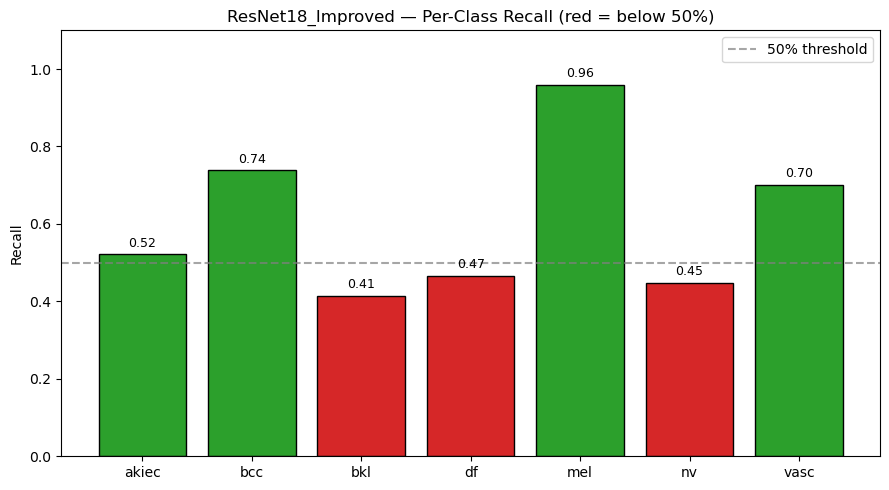

In [122]:
print('='*60)
print('Classification Report (per-class Precision / Recall / F1)')
print('='*60)
gen_classification_report(all_labels, all_preds, CLASS_NAMES)

print()
plot_per_class_recall(all_labels, all_preds, CLASS_NAMES, name='ResNet18_Improved')

##### Per-class AUC (one-vs-rest)

In [123]:
try:
    auc_scores = roc_auc_score(all_labels, all_probs, multi_class='ovr', average=None)
    print('\nPer-Class AUC (One-vs-Rest):')
    for name, auc in zip(CLASS_NAMES, auc_scores):
        print(f'  {name:8s}: {auc:.4f}')
    print(f'\n  Macro-avg AUC: {auc_scores.mean():.4f}')
except Exception as e:
    print(f'AUC skipped: {e}')


Per-Class AUC (One-vs-Rest):
  akiec   : 0.9563
  bcc     : 0.9801
  bkl     : 0.9358
  df      : 0.9854
  mel     : 0.9572
  nv      : 0.9114
  vasc    : 0.9894

  Macro-avg AUC: 0.9594


### 22. Grad-CAM Explainability

> **Improvement 3 — Grad-CAM**  
> **Fixes:** Problem 3 — No Explainability  
> **Course:** Week 5 (Backpropagation), Week 8 (CNN Architecture)
>
> The baseline is a complete black box — clinicians cannot validate its predictions. Grad-CAM (Selvaraju et al., ICCV 2017) uses the gradients flowing into the final convolutional layer to produce a heatmap showing **which image regions drove each prediction**.
>
> - No changes to model architecture — purely post-training analysis
> - Target layer: `model.layer4[-1]` (last ResNet18 conv block)
> - We verify the model focuses on the **actual lesion** rather than background

##### Grad-CAM implementation using PyTorch hooks

In [124]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Hooks into target_layer to capture activations and gradients.
    """
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor: torch.Tensor, class_idx: int = None):
        self.model.eval()
        inp = input_tensor.unsqueeze(0).to(DEVICE)
        inp.requires_grad_(True)

        logits = self.model(inp)
        if class_idx is None:
            class_idx = logits.argmax(1).item()

        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # GAP over spatial dims
        cam     = F.relu((weights * self.activations).sum(dim=1).squeeze())
        cam     = cam.cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


grad_cam = GradCAM(model, target_layer=model.layer4[-1])
print('Grad-CAM attached to model.layer4[-1]')

Grad-CAM attached to model.layer4[-1]


##### Generate and display Grad-CAM heatmaps for test samples (one per class)

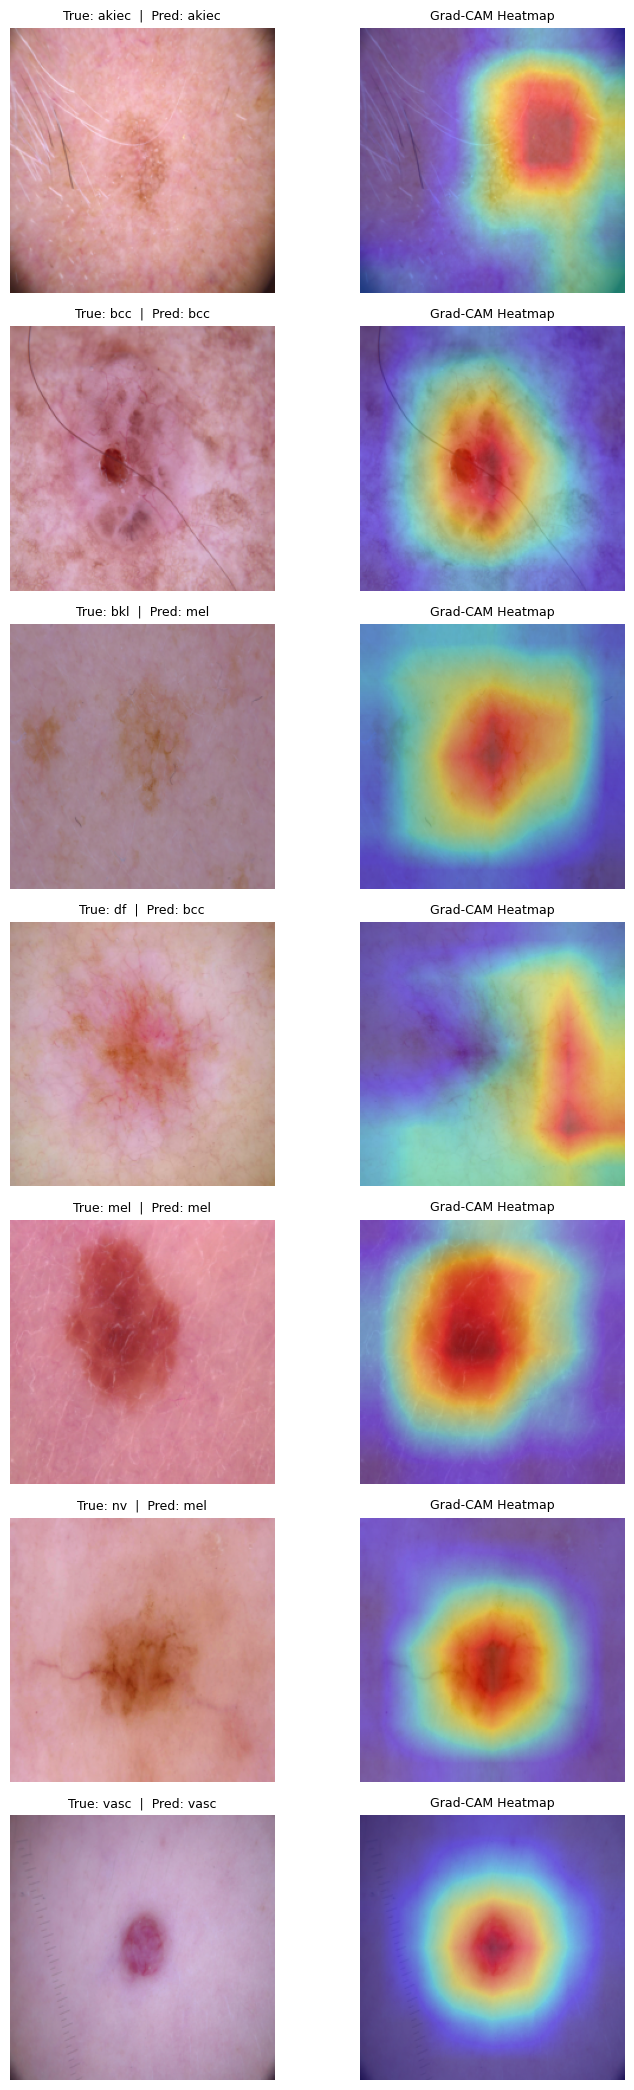

Grad-CAM figure saved to Photos/gradcam_per_class.png


In [125]:
def show_gradcam_per_class(dataset, grad_cam, class_names=CLASS_NAMES,
                           save_path='Photos/gradcam_per_class.png'):
    fig, axes = plt.subplots(len(class_names), 2, figsize=(8, 3 * len(class_names)))
    found = {c: False for c in range(len(class_names))}

    for idx in range(len(dataset)):
        img_tensor, true_label = dataset[idx]
        cls = true_label.item()
        if found[cls]:
            continue

        cam, pred_idx = grad_cam.generate(img_tensor)

        # De-normalise
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        img_disp = np.clip((img_tensor * std + mean).permute(1,2,0).numpy(), 0, 1)

        cam_resized = np.array(
            Image.fromarray((cam * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0

        row = cls
        axes[row, 0].imshow(img_disp)
        axes[row, 0].set_title(
            f'True: {class_names[cls]}  |  Pred: {class_names[pred_idx]}', fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img_disp)
        axes[row, 1].imshow(cam_resized, cmap='jet', alpha=0.45)
        axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[row, 1].axis('off')

        found[cls] = True
        if all(found.values()):
            break

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Grad-CAM figure saved to {save_path}')


show_gradcam_per_class(test_dataset, grad_cam)

### 23. Per-Label Classification Accuracy

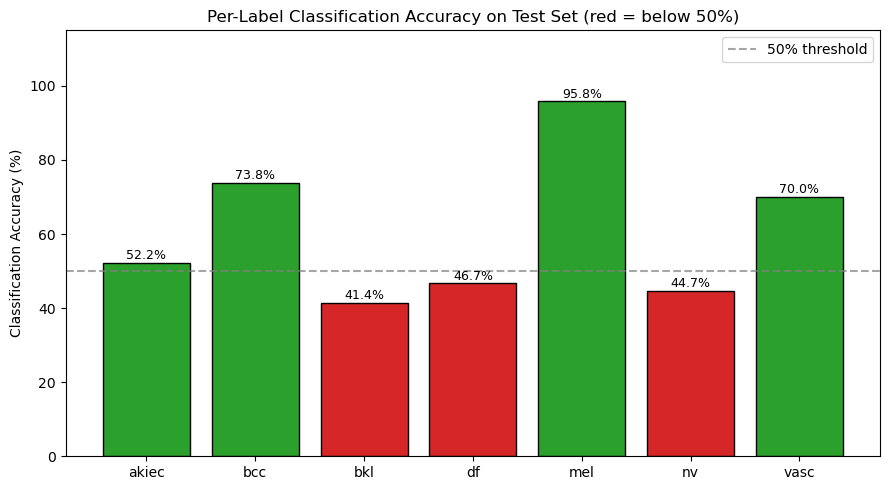

In [126]:
cm_diag   = np.diag(cm)
cm_per_cls = (cm_diag / cm.sum(axis=1)) * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(CLASS_NAMES, cm_per_cls,
               color=['#d62728' if v < 50 else '#2ca02c' for v in cm_per_cls],
               edgecolor='black')
plt.axhline(50, color='grey', linestyle='--', alpha=0.7, label='50% threshold')
plt.ylim(0, 115)
plt.ylabel('Classification Accuracy (%)')
plt.title('Per-Label Classification Accuracy on Test Set (red = below 50%)')
plt.legend()
for bar, v in zip(bars, cm_per_cls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('Photos/per_label_accuracy.png', dpi=150)
plt.show()

### 24. Results Summary

In [127]:
print('='*65)
print('FINAL RESULTS SUMMARY')
print('='*65)
print(f'Backbone       : ResNet18 (ImageNet pretrained — Transfer Learning)')
print(f'Loss Function  : Focal Loss (γ=2.0)')
print(f'Augmentation   : RandomFlip + RandomRotation + ColorJitter')
print(f'Explainability : Grad-CAM + Per-class Recall + Per-class AUC')
print(f'')
print(f'Test Accuracy  : {overall_acc*100:.2f}%   (Baseline target: ~77%  |  Our target: 85%+)')
print()
print('Per-Class Recall:')
recalls = recall_score(all_labels, all_preds, average=None, zero_division=0)
for name, rec in zip(CLASS_NAMES, recalls):
    print(f'  {name:8s}: {rec:.4f}')
try:
    print(f'\nMacro AUC: {auc_scores.mean():.4f}')
except:
    pass

FINAL RESULTS SUMMARY
Backbone       : ResNet18 (ImageNet pretrained — Transfer Learning)
Loss Function  : Focal Loss (γ=2.0)
Augmentation   : RandomFlip + RandomRotation + ColorJitter
Explainability : Grad-CAM + Per-class Recall + Per-class AUC

Test Accuracy  : 83.20%   (Baseline target: ~77%  |  Our target: 85%+)

Per-Class Recall:
  akiec   : 0.5217
  bcc     : 0.7385
  bkl     : 0.4138
  df      : 0.4667
  mel     : 0.9583
  nv      : 0.4472
  vasc    : 0.7000

Macro AUC: 0.9594
